# LIBRARIES & DATASET
importing all essential libraries and fetching dataset from kagglehub

## 1. Environment Setup
Importing all core libraries used across this project: pandas/numpy for data handling,
NLTK for text preprocessing, matplotlib/seaborn for visualization, and scikit-learn for
classical ML modeling and evaluation. NLTK resource files (stopwords, WordNet) are
downloaded here since they're required later for cleaning and lemmatization.

In [2]:
import pandas as pd
import numpy as np
import re
import string

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download NLTK resources (needed for stopwords and lemmatization)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Display settings
pd.set_option('display.max_colwidth', None)
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. Dataset Acquisition
Downloading the Sentiment140 dataset (1.6M labeled tweets) directly from Kaggle using
`kagglehub`. This dataset was chosen for its scale and topic diversity, making it
suitable for training a robust, general-purpose sentiment classifier.

from https://www.kaggle.com/datasets/kazanova/sentiment140

In [3]:
import kagglehub

# Download latest version of the Sentiment140 dataset
path = kagglehub.dataset_download("kazanova/sentiment140")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'sentiment140' dataset.
Dataset downloaded to: /kaggle/input/sentiment140


## 3. Loading the Data
Sentiment140 ships as a headerless CSV in Latin-1 encoding. We manually assign column
names and load the full dataset into a pandas DataFrame, then verify the shape and
structure look correct before proceeding.

In [4]:
import os

columns = ['target', 'ids', 'date', 'flag', 'user', 'text']

# Locate the CSV inside the downloaded folder
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_file)

# Load into a DataFrame
df = pd.read_csv(csv_path, encoding='latin-1', names=columns)

print("Shape:", df.shape)
df.head()

Shape: (1600000, 6)


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."


## 4. Label Cleanup & Class Balance Check
The raw dataset encodes sentiment as 0 (Negative) and 4 (Positive) — we remap this to
the standard 0/1 convention. We also drop unused metadata columns (user, date, etc.)
and confirm the dataset is perfectly class-balanced, which justifies using plain
accuracy as a valid evaluation metric later.

In [5]:
# Check class balance
print("Target value counts:")
print(df['target'].value_counts())

# Remap target: 0 = Negative, 4 = Positive -> 0 = Negative, 1 = Positive
df['target'] = df['target'].replace({0: 0, 4: 1})

# Keep only the columns we need for this project
df = df[['target', 'text']]

# Confirm
print("\nAfter remap:")
print(df['target'].value_counts())
df.head()

Target value counts:
target
0    800000
4    800000
Name: count, dtype: int64

After remap:
target
0    800000
1    800000
Name: count, dtype: int64


,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."


## 5. Exploratory Data Analysis — Before Preprocessing
Visual exploration of the raw dataset: class balance, tweet length distributions
(character and word count) by sentiment, most common raw words and hashtags,
punctuation intensity, and a word cloud. This establishes a baseline understanding
of the data before any cleaning is applied.

/tmp/ipykernel_24384/2099704149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette=['#d9534f','#5cb85c'])


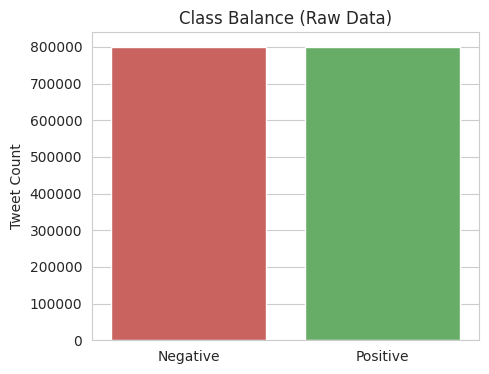

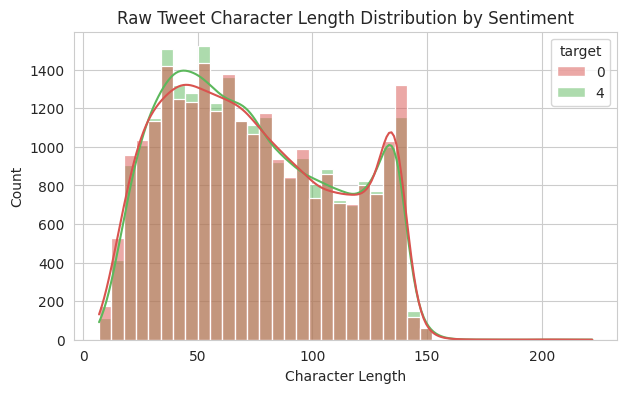

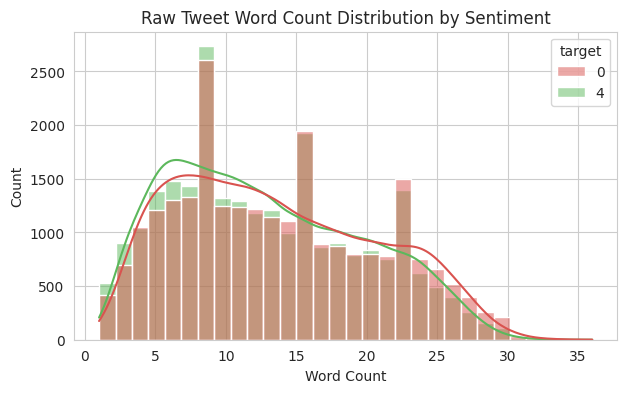

/tmp/ipykernel_24384/2099704149.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


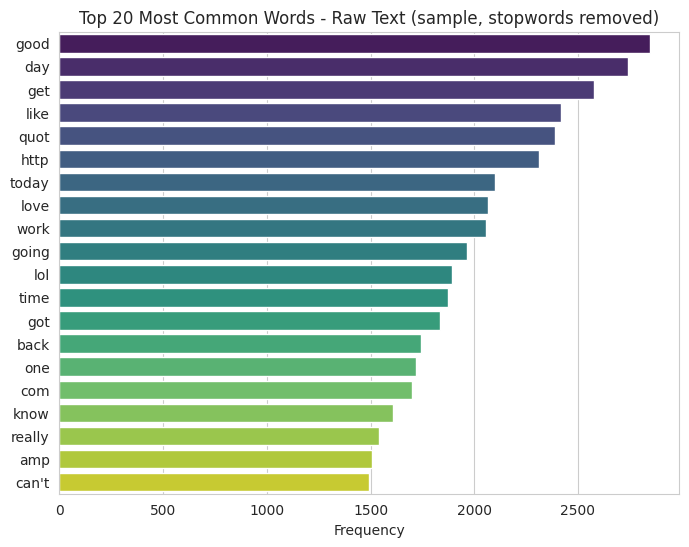

/tmp/ipykernel_24384/2099704149.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(tag_counts), y=list(tags), palette='magma')


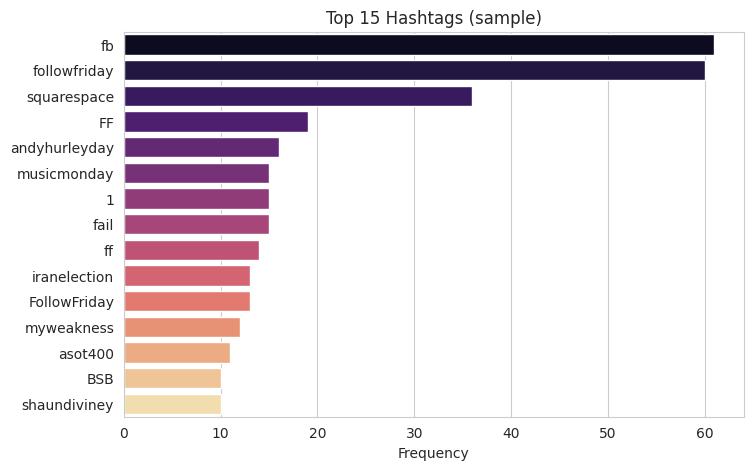

Average '!' count per tweet by sentiment:
target
0    0.481538
4    0.665900
Name: exclaim_count, dtype: float64


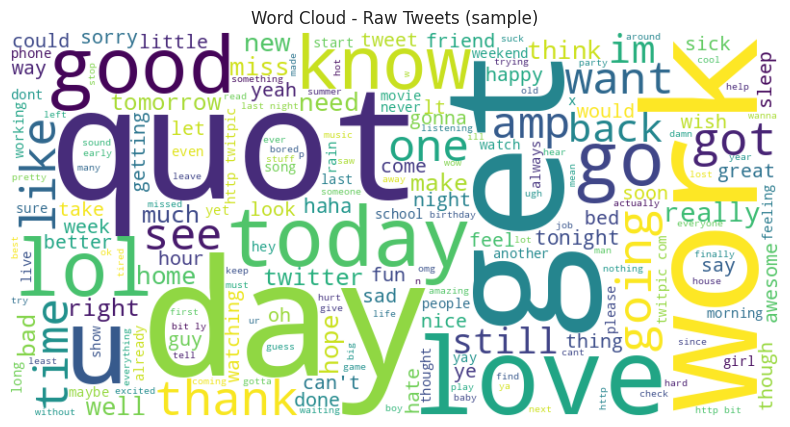

In [6]:
from collections import Counter
from wordcloud import WordCloud

# Use a random sample for expensive word-frequency/wordcloud ops (full 1.6M would be slow to tokenize)
sample_df = df.sample(50000, random_state=42)

# 1. Class balance
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df, palette=['#d9534f','#5cb85c'])
plt.xticks([0,1], ['Negative','Positive'])
plt.title('Class Balance (Raw Data)')
plt.xlabel('')
plt.ylabel('Tweet Count')
plt.show()

# 2. Tweet character length distribution
df['char_len'] = df['text'].str.len()
plt.figure(figsize=(7,4))
sns.histplot(data=df.sample(50000, random_state=42), x='char_len', hue='target', bins=40, kde=True, palette=['#d9534f','#5cb85c'])
plt.title('Raw Tweet Character Length Distribution by Sentiment')
plt.xlabel('Character Length')
plt.show()

# 3. Word count distribution
df['word_count'] = df['text'].str.split().apply(len)
plt.figure(figsize=(7,4))
sns.histplot(data=df.sample(50000, random_state=42), x='word_count', hue='target', bins=30, kde=True, palette=['#d9534f','#5cb85c'])
plt.title('Raw Tweet Word Count Distribution by Sentiment')
plt.xlabel('Word Count')
plt.show()

# 4. Most common raw words (rough tokenize, stopwords removed)
basic_stop = set(stopwords.words('english'))
def rough_tokenize(text):
    return [w.lower() for w in re.findall(r"[a-zA-Z']+", text) if w.lower() not in basic_stop and len(w) > 2]

all_words_raw = sample_df['text'].apply(rough_tokenize).sum()
top_raw_words = Counter(all_words_raw).most_common(20)
words, counts = zip(*top_raw_words)

plt.figure(figsize=(8,6))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Top 20 Most Common Words - Raw Text (sample, stopwords removed)')
plt.xlabel('Frequency')
plt.show()

# 5. Most common hashtags
hashtags = sample_df['text'].str.findall(r'#(\w+)').sum()
if hashtags:
    top_hashtags = Counter(hashtags).most_common(15)
    tags, tag_counts = zip(*top_hashtags)
    plt.figure(figsize=(8,5))
    sns.barplot(x=list(tag_counts), y=list(tags), palette='magma')
    plt.title('Top 15 Hashtags (sample)')
    plt.xlabel('Frequency')
    plt.show()
else:
    print("No hashtags found in sample.")

# 6. Punctuation intensity by sentiment
df['exclaim_count'] = df['text'].str.count('!')
print("Average '!' count per tweet by sentiment:")
print(df.groupby('target')['exclaim_count'].mean())

# 7. Word cloud - raw text
wc_text = ' '.join(sample_df['text'].sample(5000, random_state=42))
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=basic_stop).generate(wc_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Raw Tweets (sample)')
plt.show()

## 6. Text Cleaning Function
Defining our tweet preprocessing pipeline: lowercasing, contraction expansion, URL/
mention removal, hashtag normalization, repeated-character reduction, punctuation
removal, stopword removal, and lemmatization. Tested on a small sample first to
visually verify correctness before applying it to the full dataset.

**Known limitation:** lemmatization defaults to noun-POS tagging (no explicit
part-of-speech tagging was used, for performance reasons on 1.6M rows), so some
verb forms (e.g. "texting") aren't reduced to their root ("text"). This is a
documented tradeoff, not a bug.

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

contractions = {
    "can't": "cannot", "won't": "will not", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would",
    "'ll": " will", "'t": " not", "'ve": " have", "'m": " am"}

def clean_tweet(text):
  text = text.lower()
  for contraction, expansion in contractions.items():
    text = text.replace(contraction, expansion)

  text = re.sub(r'http\S+|www\S+|https\S+', '', text)
  text = re.sub(r'@\w+', '', text)
  text = re.sub(r'#(\w+)', '\1', text)
  text = re.sub(r'(.)\1{2,}', r'\1\1', text)
  text = re.sub(r'[^a-z\s]', '', text)

  words = text.split()
  words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 1]

  return " ".join(words)

In [8]:
sample_tweets = df['text'].sample(5, random_state=42)
for tweet in sample_tweets:
  print('RAW: ', tweet)
  print('cleaned data: ', clean_tweet(tweet))

RAW:  @chrishasboobs AHHH I HOPE YOUR OK!!! 
cleaned data:  ahh hope ok
RAW:  @misstoriblack cool , i have no tweet apps  for my razr 2
cleaned data:  cool tweet apps razr
RAW:  @TiannaChaos i know  just family drama. its lame.hey next time u hang out with kim n u guys like have a sleepover or whatever, ill call u
cleaned data:  know family drama lamehey next time hang kim guy like sleepover whatever ill call
RAW:  School email won't open  and I have geography stuff on there to revise! *Stupid School* :'(
cleaned data:  school email open geography stuff revise stupid school
RAW:  upper airways problem 
cleaned data:  upper airway problem


## 7. Applying Cleaning to the Full Dataset
Running the cleaning function across all 1.6M tweets and storing results in a new
`clean_text` column. Rows that became empty after cleaning (e.g. tweets that were
just a URL or mention) are dropped, since they carry no usable signal.

In [9]:
import time
start = time.time()
df['clean_text'] = df['text'].apply(clean_tweet)
end = time.time()
print(f"Cleaning completed in {end - start:.1f} seconds")

# Drop any rows that became empty after cleaning (e.g. tweets that were only a URL/mention)
before = len(df)
df = df[df['clean_text'].str.strip() != '']
after = len(df)
print(f"Dropped {before - after} rows that became empty after cleaning")

df.head()

Cleaning completed in 57.4 seconds
Dropped 8962 rows that became empty after cleaning


,target,text,char_len,word_count,exclaim_count,clean_text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D",115,19,0,bummer shoulda got david carr third day
1,0,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,111,21,1,upset cannot update facebook texting might cry result school today also blah
2,0,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,89,18,0,dived many time ball managed save rest go bound
3,0,my whole body feels itchy and like its on fire,47,10,0,whole body feel itchy like fire
4,0,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.",111,21,0,behaving mad cannot see


## 8. Exploratory Data Analysis — After Preprocessing
Re-examining the dataset after cleaning: word count distribution shift, most
common words per sentiment class, sentiment-specific word clouds, and top bigrams
— the latter directly validating our choice to use bigram features in the TF-IDF
step that follows.

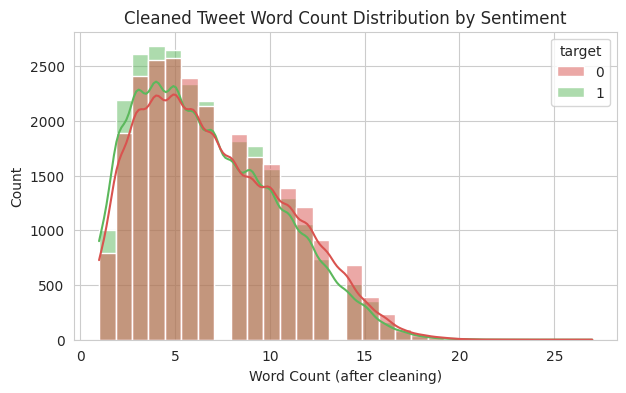

Average word count BEFORE cleaning: 13.23
Average word count AFTER cleaning:  6.84


/tmp/ipykernel_1914/3090285342.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Before Cleaning', 'After Cleaning'], y=[avg_before, avg_after], palette=['#f0ad4e','#5bc0de'])


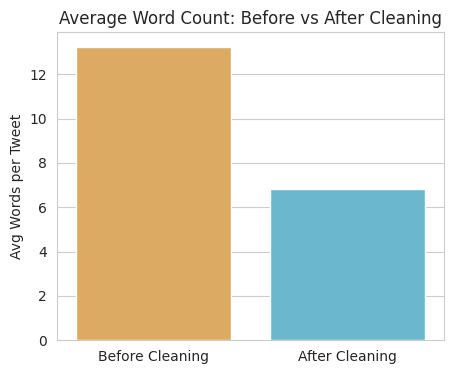

/tmp/ipykernel_1914/3090285342.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_p), y=list(words_p), ax=axes[0], palette='Greens_r')
/tmp/ipykernel_1914/3090285342.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_n), y=list(words_n), ax=axes[1], palette='Reds_r')


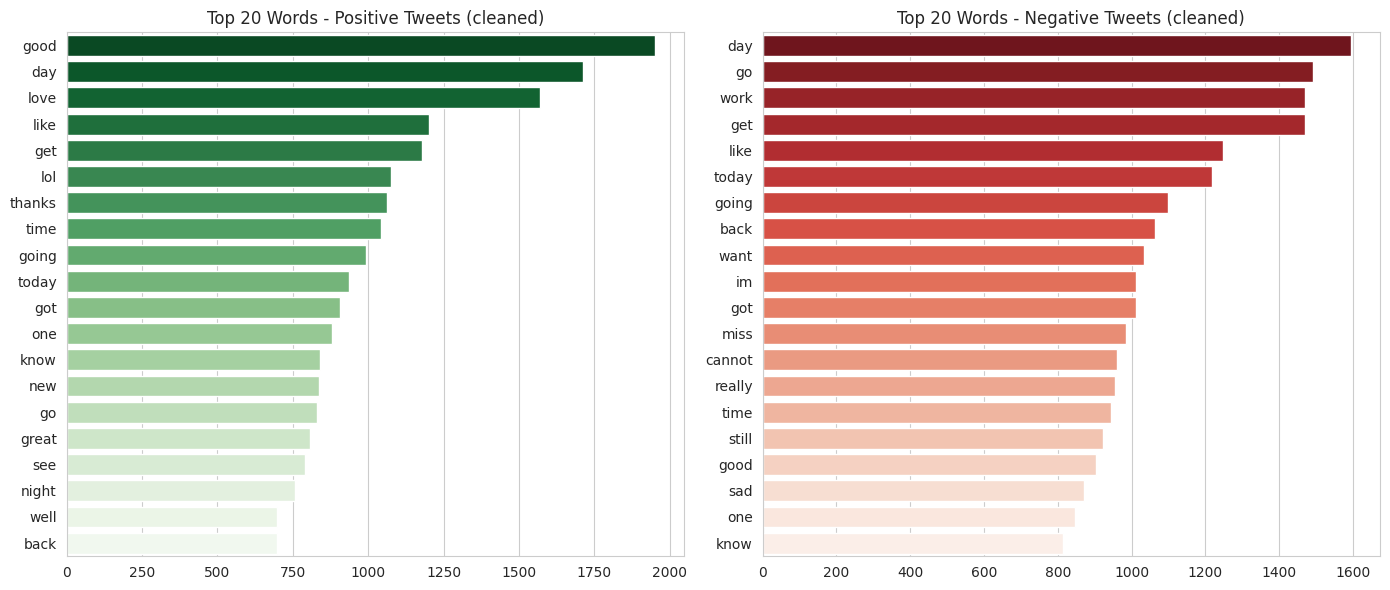

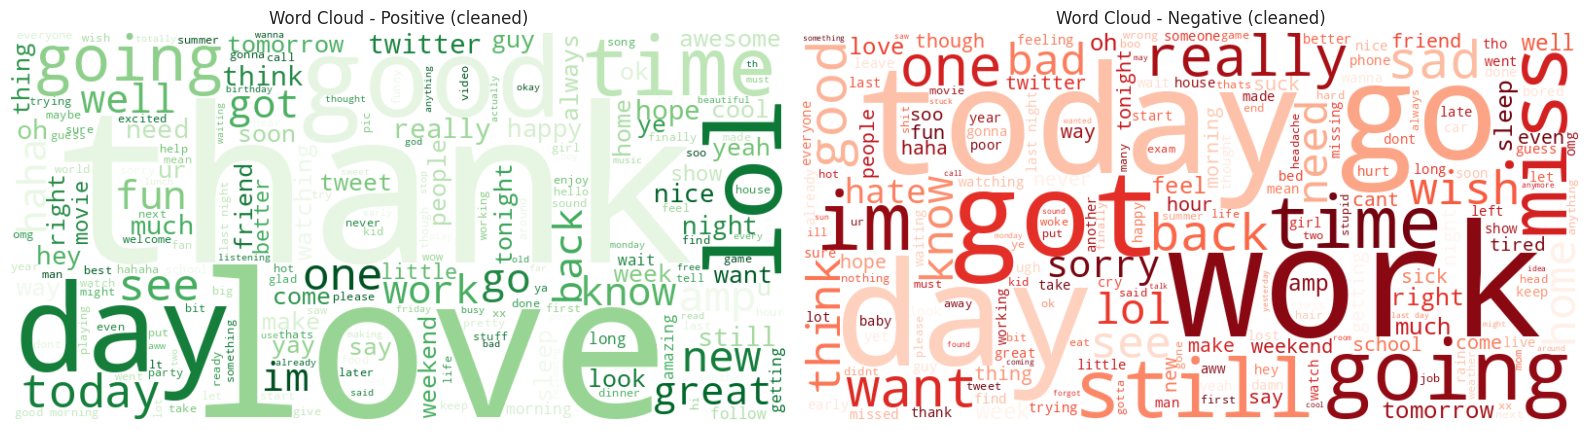

/tmp/ipykernel_1914/3090285342.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='bigram', data=bigram_df, palette='coolwarm')


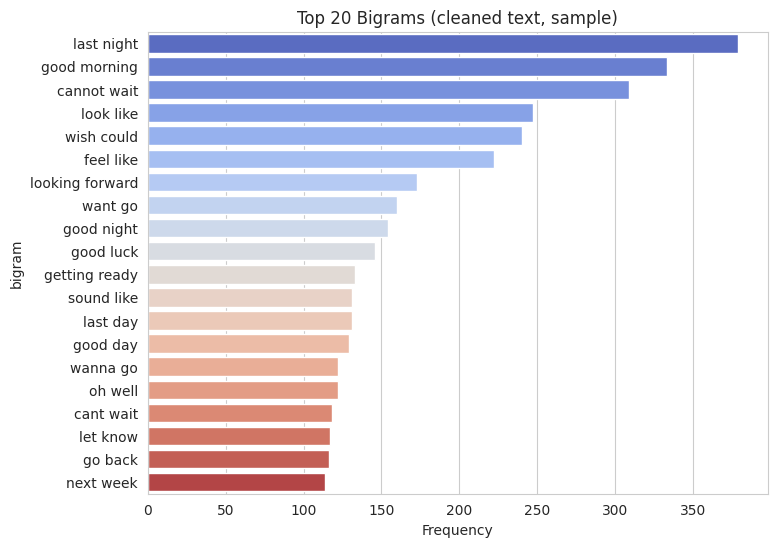

In [10]:
# 1. Cleaned tweet word count distribution
df['clean_word_count'] = df['clean_text'].str.split().apply(len)

plt.figure(figsize=(7,4))
sns.histplot(data=df.sample(50000, random_state=42), x='clean_word_count', hue='target', bins=30, kde=True, palette=['#d9534f','#5cb85c'])
plt.title('Cleaned Tweet Word Count Distribution by Sentiment')
plt.xlabel('Word Count (after cleaning)')
plt.show()

# 2. Before vs after average word count comparison
avg_before = df['word_count'].mean()
avg_after = df['clean_word_count'].mean()
print(f"Average word count BEFORE cleaning: {avg_before:.2f}")
print(f"Average word count AFTER cleaning:  {avg_after:.2f}")

plt.figure(figsize=(5,4))
sns.barplot(x=['Before Cleaning', 'After Cleaning'], y=[avg_before, avg_after], palette=['#f0ad4e','#5bc0de'])
plt.title('Average Word Count: Before vs After Cleaning')
plt.ylabel('Avg Words per Tweet')
plt.show()

# 3. Most common cleaned words per sentiment class
sample_clean = df.sample(50000, random_state=42)
pos_words = sample_clean[sample_clean['target']==1]['clean_text'].str.split().sum()
neg_words = sample_clean[sample_clean['target']==0]['clean_text'].str.split().sum()

top_pos = Counter(pos_words).most_common(20)
top_neg = Counter(neg_words).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
words_p, counts_p = zip(*top_pos)
sns.barplot(x=list(counts_p), y=list(words_p), ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 20 Words - Positive Tweets (cleaned)')

words_n, counts_n = zip(*top_neg)
sns.barplot(x=list(counts_n), y=list(words_n), ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 20 Words - Negative Tweets (cleaned)')
plt.tight_layout()
plt.show()

# 4. Word clouds per sentiment class (cleaned text)
pos_text = ' '.join(sample_clean[sample_clean['target']==1]['clean_text'].sample(5000, random_state=42))
neg_text = ' '.join(sample_clean[sample_clean['target']==0]['clean_text'].sample(5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(16,6))
wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud - Positive (cleaned)')

wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud - Negative (cleaned)')
plt.tight_layout()
plt.show()

# 5. Top bigrams after cleaning (ties directly to our TF-IDF ngram_range=(1,2) choice)
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
bigram_matrix = bigram_vectorizer.fit_transform(sample_clean['clean_text'])
bigram_counts = bigram_matrix.sum(axis=0).A1
bigram_names = bigram_vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({'bigram': bigram_names, 'count': bigram_counts}).sort_values('count', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='count', y='bigram', data=bigram_df, palette='coolwarm')
plt.title('Top 20 Bigrams (cleaned text, sample)')
plt.xlabel('Frequency')
plt.show()

## 9. Train/Test Split & Feature Engineering (TF-IDF)
Splitting the data before vectorizing to avoid data leakage. Building a TF-IDF
feature matrix using unigrams and bigrams (to capture short phrases like "not
good"), with vocabulary capped at 50,000 terms for memory efficiency.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],df['target'],test_size=0.2,random_state=42,stratify=df['target'])

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


tfidf = TfidfVectorizer(max_features=50000,ngram_range=(1, 2),min_df=5)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF matrix shape (test):", X_test_tfidf.shape)

Train size: 1272830
Test size: 318208
TF-IDF matrix shape (train): (1272830, 50000)
TF-IDF matrix shape (test): (318208, 50000)


## 10. Baseline Model — Logistic Regression
Training a Logistic Regression classifier on the TF-IDF features as our baseline
model — fast, interpretable, and a standard first choice for text classification.

In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

start = time.time()
log_reg.fit(X_train_tfidf, y_train)
end = time.time()

print(f"Training completed in {end - start:.1f} seconds")

# Predict on test set
y_pred = log_reg.predict(X_test_tfidf)

print("Baseline Logistic Regression trained and predictions generated.")

Training completed in 26.0 seconds
Baseline Logistic Regression trained and predictions generated.


Accuracy: 0.7898

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.77      0.79    159165
    Positive       0.78      0.81      0.79    159043

    accuracy                           0.79    318208
   macro avg       0.79      0.79      0.79    318208
weighted avg       0.79      0.79      0.79    318208



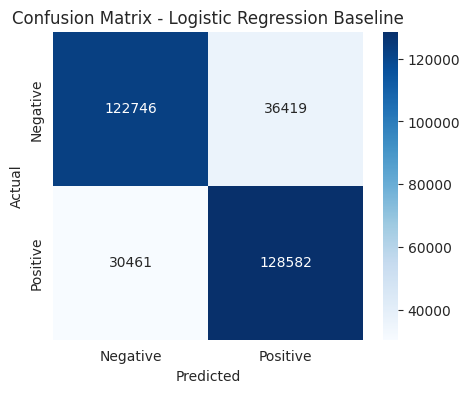

In [14]:
# Overall accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")

# Detailed precision/recall/F1 per class
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression Baseline')
plt.show()

## 11. Model Interpretability — Top Predictive Words
Inspecting the Logistic Regression model's learned coefficients to see which
words/phrases most strongly drive Positive vs. Negative predictions. This serves
as both a sanity check and a genuine interpretability feature.

In [17]:
# Get feature names and their corresponding model weights
feature_names = np.array(tfidf.get_feature_names_out())
coefs = log_reg.coef_[0]

# Top 15 words pushing toward POSITIVE
top_positive_idx = np.argsort(coefs)[-15:][::-1]
print("Top 15 words/phrases driving POSITIVE sentiment:")
for idx in top_positive_idx:
    print(f"  {feature_names[idx]:20s}  weight: {coefs[idx]:.3f}")

print()

# Top 15 words pushing toward NEGATIVE
top_negative_idx = np.argsort(coefs)[:15]
print("Top 15 words/phrases driving NEGATIVE sentiment:")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]:20s}  weight: {coefs[idx]:.3f}")

Top 15 words/phrases driving POSITIVE sentiment:
  cannot wait           weight: 9.548
  cant wait             weight: 8.046
  wish luck             weight: 6.396
  nothing wrong         weight: 5.779
  welcome               weight: 5.467
  smiling               weight: 5.163
  thank                 weight: 4.958
  congratulation        weight: 4.927
  made day              weight: 4.783
  thanks                weight: 4.683
  get enough            weight: 4.441
  glad                  weight: 4.394
  smile                 weight: 4.384
  blessed               weight: 4.369
  yay                   weight: 4.249

Top 15 words/phrases driving NEGATIVE sentiment:
  sad                   weight: -13.906
  bummed                weight: -9.048
  sick                  weight: -7.834
  sadly                 weight: -7.807
  poor                  weight: -7.775
  gutted                weight: -7.766
  missing               weight: -7.519
  miss                  weight: -7.263
  cancelled       

## 12. Topic-Level Sentiment Analysis (Initial Version)
A reusable function that filters tweets by keyword/topic and reports the model's
sentiment breakdown for that subset — directly addressing the project goal of
analyzing public sentiment on specific topics.

Topic: 'GOD'
Tweets analyzed: 11774
Positive: 54.3%  |  Negative: 45.7%



/tmp/ipykernel_1914/3981396632.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='predicted_sentiment', data=topic_tweets, order=['Negative', 'Positive'], palette=['#d9534f', '#5cb85c'])


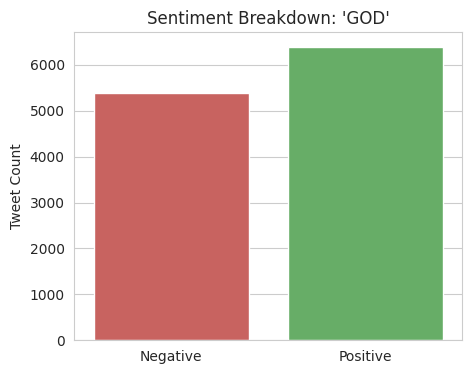

,text,predicted_sentiment
441,Good GOD they ruined my belly button!!!,Negative
529,I am officially banning godaddy.com from my comp. My head hurts from the small print AND I wasted $10 that could've happily gone to Boba,Negative
884,"So... Tired... God I hate the new job, and only two days in",Negative
1058,@sensesdestroyer I wanna go to lamb of god,Negative
1265,It's official! I'm going to have an educational summer. Owh God. Bless me,Positive
1465,oh god one of the teachers here gave me a rotten gogoma to eat.. and i'm so hungry i'm trying to eat around the bad parts HAHAHAHA,Negative
1515,I cried when I heard the girl from Tracy was found today. It was soooo sad May god bless Sandra Cantu.,Negative
1534,"@TexasVegetarian Oh, God, ow. That must have hurt like a bitch.",Negative
1906,"@MissCassandra StiLL on my &quot;Lions &amp; Tigers &amp; Bears&quot; shyt............. but GOD is gOOd consequently, I wiLL be tOO",Positive
1954,I am engaged to muppet orlando and i just realised oh my god i cant marry Justin Timberlake,Negative


In [18]:
def analyze_topic_sentiment(topic, dataframe=df, model=log_reg, vectorizer=tfidf):
    topic_tweets = dataframe[dataframe['text'].str.contains(topic, case=False, na=False)].copy()

    if len(topic_tweets) == 0:
        print(f"No tweets found mentioning '{topic}'.")
        return None

    topic_features = vectorizer.transform(topic_tweets['clean_text'])

    # Predict sentiment
    predictions = model.predict(topic_features)
    topic_tweets['predicted_sentiment'] = np.where(predictions == 1, 'Positive', 'Negative')

    # Summarize
    total = len(topic_tweets)
    pos_pct = (predictions == 1).mean() * 100
    neg_pct = (predictions == 0).mean() * 100

    print(f"Topic: '{topic}'")
    print(f"Tweets analyzed: {total}")
    print(f"Positive: {pos_pct:.1f}%  |  Negative: {neg_pct:.1f}%\n")

    # Plot
    plt.figure(figsize=(5, 4))
    sns.countplot(x='predicted_sentiment', data=topic_tweets, order=['Negative', 'Positive'], palette=['#d9534f', '#5cb85c'])
    plt.title(f"Sentiment Breakdown: '{topic}'")
    plt.xlabel('')
    plt.ylabel('Tweet Count')
    plt.show()

    return topic_tweets[['text', 'predicted_sentiment']]

# Test it on a sample topic
result = analyze_topic_sentiment('GOD')
result.head(10)

## 13. Model Comparison — Multinomial Naive Bayes
Training a Naive Bayes classifier on the same TF-IDF features, for a fair
side-by-side comparison against Logistic Regression.

Naive Bayes training completed in 0.2 seconds

Naive Bayes Accuracy: 0.7731

Classification Report (Naive Bayes):
              precision    recall  f1-score   support

    Negative       0.77      0.77      0.77    159165
    Positive       0.77      0.78      0.77    159043

    accuracy                           0.77    318208
   macro avg       0.77      0.77      0.77    318208
weighted avg       0.77      0.77      0.77    318208



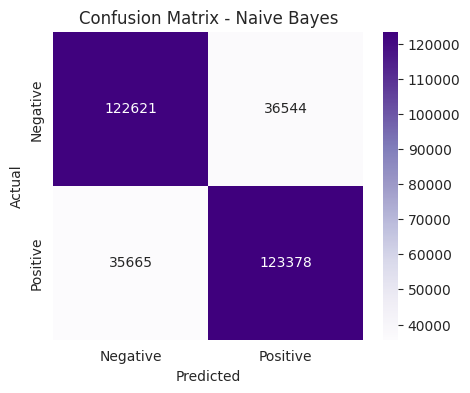

In [13]:
from sklearn.naive_bayes import MultinomialNB

# Train Naive Bayes on the same TF-IDF features as before
nb_model = MultinomialNB()

start = time.time()
nb_model.fit(X_train_tfidf, y_train)
end = time.time()
print(f"Naive Bayes training completed in {end - start:.1f} seconds")

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test_tfidf)

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"\nNaive Bayes Accuracy: {acc_nb:.4f}\n")
print("Classification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))

cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

## 14. Model Comparison — Linear SVM
Training a Linear Support Vector Machine on the same features. Unlike Logistic
Regression's probabilistic approach, SVM finds the maximum-margin boundary between
classes.

SVM training completed in 129.8 seconds

SVM Accuracy: 0.7866

Classification Report (SVM):
              precision    recall  f1-score   support

    Negative       0.80      0.77      0.78    159165
    Positive       0.77      0.81      0.79    159043

    accuracy                           0.79    318208
   macro avg       0.79      0.79      0.79    318208
weighted avg       0.79      0.79      0.79    318208



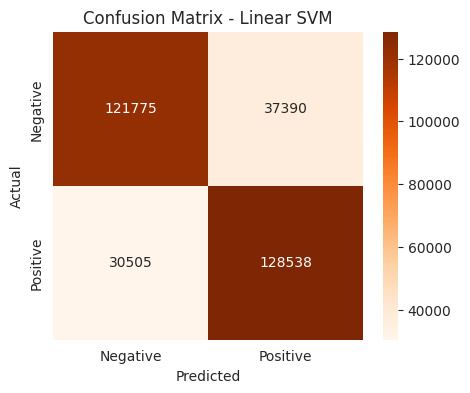

In [15]:
from sklearn.svm import LinearSVC

# Train Linear SVM on the same TF-IDF features
svm_model = LinearSVC(random_state=42, max_iter=2000)

start = time.time()
svm_model.fit(X_train_tfidf, y_train)
end = time.time()
print(f"SVM training completed in {end - start:.1f} seconds")

# Predict and evaluate
y_pred_svm = svm_model.predict(X_test_tfidf)

acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"\nSVM Accuracy: {acc_svm:.4f}\n")
print("Classification Report (SVM):")
print(classification_report(y_test, y_pred_svm, target_names=['Negative', 'Positive']))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Linear SVM')
plt.show()

## 15. Deep Learning Pipeline — Tokenization & Sequence Padding
Preparing data for an LSTM model, which requires ordered word sequences rather
than TF-IDF's bag-of-words representation. Tweets are tokenized into integer
sequences and padded to a fixed length. Trained on the full 1.6M-tweet dataset
using a T4 GPU runtime.

In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Confirm GPU is active
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))

X_lstm = df['clean_text']
y_lstm = df['target']


X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_lstm, y_lstm, test_size=0.2, random_state=42, stratify=y_lstm
)

# Tokenizer: converts words to integer indices
MAX_VOCAB = 30000
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_lstm)

# Convert text to sequences of integers
train_sequences = tokenizer.texts_to_sequences(X_train_lstm)
test_sequences = tokenizer.texts_to_sequences(X_test_lstm)

# Pad sequences to a fixed length
MAX_LEN = 40
X_train_pad = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print("Train shape:", X_train_pad.shape)
print("Test shape:", X_test_pad.shape)
print("\nExample - original text:", X_train_lstm.iloc[0])
print("Example - as sequence:", train_sequences[0])
print("Example - padded:", X_train_pad[0])

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train shape: (1272830, 40)
Test shape: (318208, 40)

Example - original text: stupid brooke marathon missing daisy love tonight need trashfest
Example - as sequence: [293, 4311, 1365, 229, 2555, 7, 56, 28, 1]
Example - padded: [ 293 4311 1365  229 2555    7   56   28    1    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]


## 16. LSTM Model Architecture
Building a sequential deep learning model: an Embedding layer to learn dense word
representations, an LSTM layer to capture word order and context (e.g. negation),
and dense layers for final classification.

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, SpatialDropout1D

EMBEDDING_DIM = 100

model_lstm = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBEDDING_DIM),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 40, 100)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 40, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,044,353 (11.61 MB)

 Trainable params: 3,044,353 (11.61 MB)

 Non-trainable params: 0 (0.00 B)

## 17. Training the LSTM
Training the LSTM with early stopping (to prevent overfitting) and a validation
split for monitoring.

**Note:** training was capped at 5 epochs due to compute-time constraints;
validation loss was still improving at that point, so this result reflects a
deliberate time/performance tradeoff rather than full convergence.

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

start = time.time()

history = model_lstm.fit(
    X_train_pad, y_train_lstm,
    validation_split=0.1,
    epochs=5,
    batch_size=512,
    callbacks=[early_stop]
)

end = time.time()
print(f"\nTraining completed in {(end - start)/60:.1f} minutes")

Epoch 1/5
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 355s 155ms/step - accuracy: 0.6257 - loss: 0.6526 - val_accuracy: 0.6686 - val_loss: 0.6339
Epoch 2/5
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 348s 155ms/step - accuracy: 0.6670 - loss: 0.6366 - val_accuracy: 0.6713 - val_loss: 0.6330
Epoch 3/5
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 350s 157ms/step - accuracy: 0.6746 - loss: 0.6325 - val_accuracy: 0.6785 - val_loss: 0.6257
Epoch 4/5
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 375s 167ms/step - accuracy: 0.6786 - loss: 0.6303 - val_accuracy: 0.6787 - val_loss: 0.6253
Epoch 5/5
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 396s 177ms/step - accuracy: 0.7524 - loss: 0.5134 - val_accuracy: 0.7845 - val_loss: 0.4541

Training completed in 30.4 minutes


## 18. LSTM Test Set Evaluation
Evaluating the trained LSTM on the held-out test set using the same metrics as
the classical models, plus training history curves to visualize the loss/accuracy
trajectory across epochs.

622/622 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step
LSTM Test Accuracy: 0.7847

Classification Report (LSTM):
              precision    recall  f1-score   support

    Negative       0.78      0.79      0.79    159165
    Positive       0.79      0.78      0.78    159043

    accuracy                           0.78    318208
   macro avg       0.78      0.78      0.78    318208
weighted avg       0.78      0.78      0.78    318208



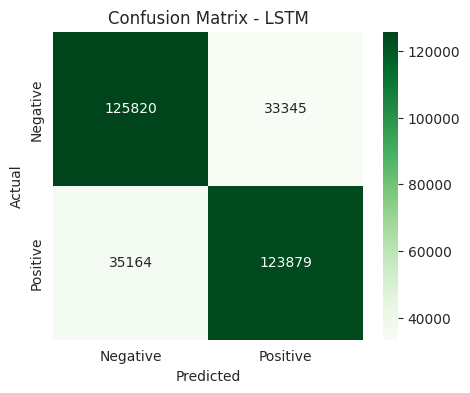

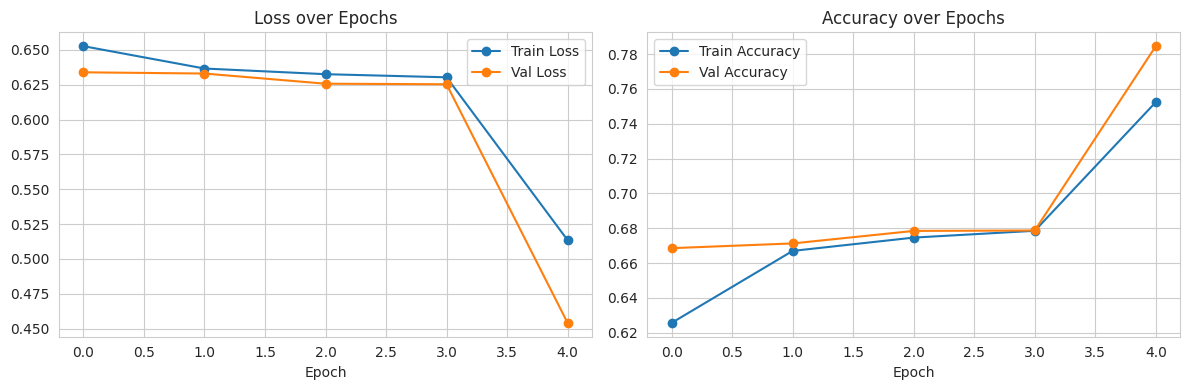

In [22]:
# Predict on the true test set (never touched during training)
y_pred_lstm_probs = model_lstm.predict(X_test_pad, batch_size=512)
y_pred_lstm = (y_pred_lstm_probs > 0.5).astype(int).flatten()

acc_lstm = accuracy_score(y_test_lstm, y_pred_lstm)
print(f"LSTM Test Accuracy: {acc_lstm:.4f}\n")
print("Classification Report (LSTM):")
print(classification_report(y_test_lstm, y_pred_lstm, target_names=['Negative', 'Positive']))

cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LSTM')
plt.show()

# Plot training history (loss and accuracy curves)
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(history.history['loss'], label='Train Loss', marker='o')
axes[0].plot(history.history['val_loss'], label='Val Loss', marker='o')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 19. Final Model Comparison
Comparing all four models — Logistic Regression, Naive Bayes, Linear SVM, and
LSTM — side-by-side on the same held-out test set.

                 Model  Accuracy
0  Logistic Regression  0.789823
1           Linear SVM  0.786633
2                 LSTM  0.784704
3          Naive Bayes  0.773076


/tmp/ipykernel_1914/3986943505.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Accuracy', y='Model', data=results, palette='viridis')


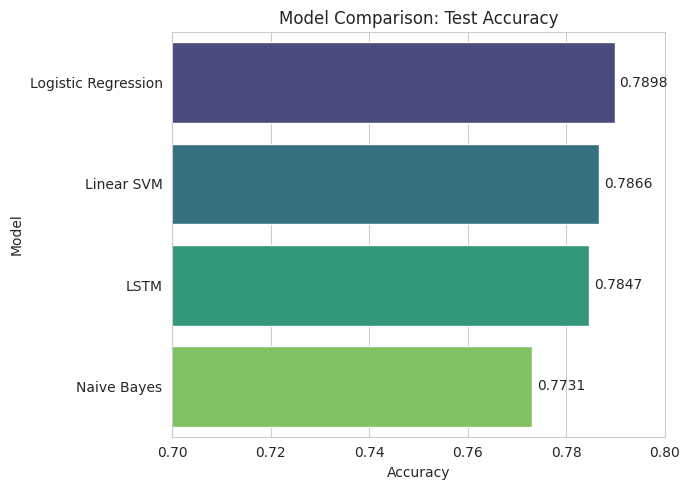

In [23]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Linear SVM', 'LSTM'],
    'Accuracy': [acc, acc_nb, acc_svm, acc_lstm]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(results)

plt.figure(figsize=(7,5))
bars = sns.barplot(x='Accuracy', y='Model', data=results, palette='viridis')
plt.xlim(0.70, 0.80)
plt.title('Model Comparison: Test Accuracy')
plt.xlabel('Accuracy')

# Add value labels on bars
for i, v in enumerate(results['Accuracy']):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

## 20. Enhancement — Confidence-Based Neutral Zone
Sentiment140 only provides binary labels (no Neutral class). Using the best
model's prediction probabilities, we introduce a confidence threshold band
(0.40–0.60) to flag low-confidence predictions as "Neutral" rather than forcing
every tweet into Positive or Negative. This required no retraining — only
reinterpreting the model's existing probability outputs.

Distribution with Neutral zone added:
Positive    139387
Negative    128983
Neutral      49838
Name: count, dtype: int64

15.66% of test tweets fell into the low-confidence Neutral zone
(these were previously force-labeled Positive/Negative despite the model being unsure)



/tmp/ipykernel_1914/780890736.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred_3class, order=['Negative', 'Neutral', 'Positive'], palette=['#d9534f', '#f0ad4e', '#5cb85c'])


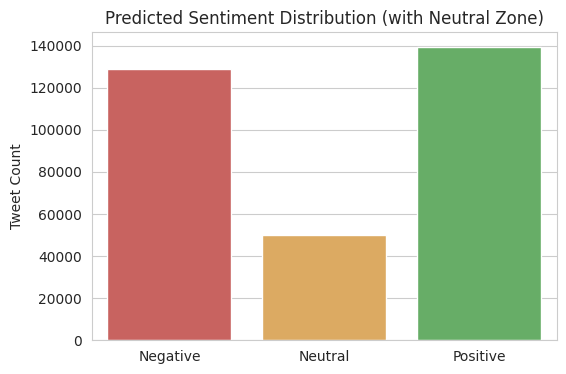

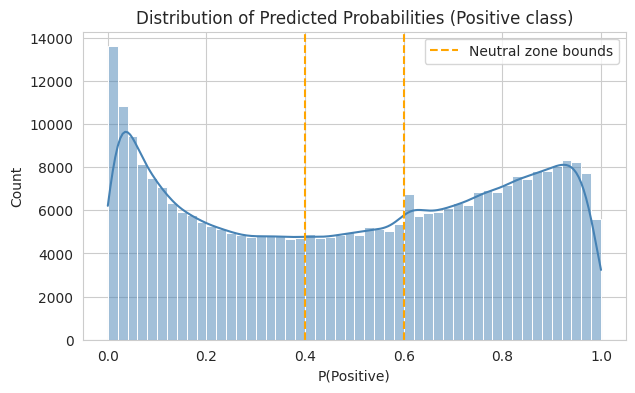

In [24]:
# Get raw probability scores from our best model (Logistic Regression)
y_pred_proba = log_reg.predict_proba(X_test_tfidf)[:, 1]  # probability of class 1 (Positive)

# Define confidence thresholds for the neutral zone
LOWER_THRESHOLD = 0.40
UPPER_THRESHOLD = 0.60

def classify_with_neutral(prob):
    if prob < LOWER_THRESHOLD:
        return 'Negative'
    elif prob > UPPER_THRESHOLD:
        return 'Positive'
    else:
        return 'Neutral'

y_pred_3class = pd.Series(y_pred_proba).apply(classify_with_neutral)

# How many tweets fall into each bucket now?
print("Distribution with Neutral zone added:")
print(y_pred_3class.value_counts())
print()

# What % of original hard-labeled predictions were actually low-confidence?
neutral_pct = (y_pred_3class == 'Neutral').mean() * 100
print(f"{neutral_pct:.2f}% of test tweets fell into the low-confidence Neutral zone")
print(f"(these were previously force-labeled Positive/Negative despite the model being unsure)\n")

# Visualize
plt.figure(figsize=(6,4))
sns.countplot(x=y_pred_3class, order=['Negative', 'Neutral', 'Positive'], palette=['#d9534f', '#f0ad4e', '#5cb85c'])
plt.title('Predicted Sentiment Distribution (with Neutral Zone)')
plt.xlabel('')
plt.ylabel('Tweet Count')
plt.show()

# Distribution of confidence scores overall (helps justify our threshold choice)
plt.figure(figsize=(7,4))
sns.histplot(y_pred_proba, bins=50, kde=True, color='steelblue')
plt.axvline(LOWER_THRESHOLD, color='orange', linestyle='--', label='Neutral zone bounds')
plt.axvline(UPPER_THRESHOLD, color='orange', linestyle='--')
plt.title('Distribution of Predicted Probabilities (Positive class)')
plt.xlabel('P(Positive)')
plt.legend()
plt.show()

## 21. Interactive Demo — Topic Sentiment Analysis
A live, interactive cell: enter any keyword or topic, and get an instant
sentiment breakdown (Positive/Neutral/Negative) across matching tweets from the
dataset, complete with a visual chart and example tweets at each end of the
confidence spectrum.

Enter a topic/keyword to analyze sentiment for: facebook
Topic: 'facebook'  |  Tweets analyzed: 4756

  Positive :  49.1%  (2337 tweets)
  Neutral  :  16.8%  (797 tweets)
  Negative :  34.1%  (1622 tweets)


/tmp/ipykernel_1914/996466577.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='predicted_sentiment', data=topic_tweets,


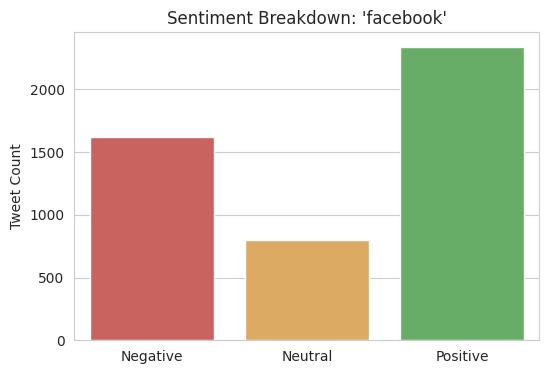


Sample tweets:


,text,sentiment_score,predicted_sentiment
143384,Tyrell sadly died always missed! http://apps.facebook.com/catbook/profile/view/1300501,0.000083,Negative
2251,Mitea is missing http://apps.facebook.com/catbook/profile/view/6040269,0.000862,Negative
126377,"Gahhh sch is a bore when there's nothing to do, and all sites/apps(aim,twitter,facebook,hotmail,etc) have been blocked! sad sad times lol",0.000927,Negative
715061,bored.. facebook and twitter jus dnt cut 4 entertainment anymore wat a sad sad time,0.001128,Negative
236192,Jellybean has a sick tummy http://apps.facebook.com/dogbook/profile/view/6848929,0.001229,Negative


,text,sentiment_score,predicted_sentiment
1066319,@sethsimonds I'm assuming your Facebook family is also your REAL family? Congratulations if that is true. You are truly blessed.,0.988683,Positive
1284548,thanks to facebook my long-lost friend found me! haha yayy im sooo happy !,0.989559,Positive
1428828,"@ServerMonkey Thank you! I am more of a facebooker now, but I&quot;ll tweet here and there",0.990703,Positive
954569,@estockcouk; @efusjonfacebook; @Winospace; @DaEmptyPrincess; @PWMLtd; @zarvo; @affiliatelady; @blander555: Thanks for the follow!,0.990938,Positive
1039514,Yay it worked hello twitter/facebook! This is cool...,0.995953,Positive


In [27]:
def analyze_topic_sentiment_v2(topic, dataframe=df, model=log_reg, vectorizer=tfidf,
                                 lower=0.40, upper=0.60):
    topic_tweets = dataframe[dataframe['text'].str.contains(topic, case=False, na=False)].copy()

    if len(topic_tweets) == 0:
        print(f"No tweets found mentioning '{topic}'.")
        return None

    topic_features = vectorizer.transform(topic_tweets['clean_text'])
    probs = model.predict_proba(topic_features)[:, 1]

    topic_tweets['sentiment_score'] = probs
    topic_tweets['predicted_sentiment'] = pd.Series(probs, index=topic_tweets.index).apply(
        lambda p: 'Negative' if p < lower else ('Positive' if p > upper else 'Neutral')
    )

    total = len(topic_tweets)
    counts = topic_tweets['predicted_sentiment'].value_counts()

    print(f"Topic: '{topic}'  |  Tweets analyzed: {total}\n")
    for label in ['Positive', 'Neutral', 'Negative']:
        pct = (counts.get(label, 0) / total) * 100
        print(f"  {label:9s}: {pct:5.1f}%  ({counts.get(label, 0)} tweets)")

    plt.figure(figsize=(6,4))
    sns.countplot(x='predicted_sentiment', data=topic_tweets,
                  order=['Negative', 'Neutral', 'Positive'],
                  palette=['#d9534f', '#f0ad4e', '#5cb85c'])
    plt.title(f"Sentiment Breakdown: '{topic}'")
    plt.xlabel('')
    plt.ylabel('Tweet Count')
    plt.show()

    return topic_tweets[['text', 'sentiment_score', 'predicted_sentiment']].sort_values('sentiment_score')

# --- Interactive input ---
user_topic = input("Enter a topic/keyword to analyze sentiment for: ")
result = analyze_topic_sentiment_v2(user_topic)

if result is not None:
    print("\nSample tweets:")
    display(result.head(5))
    display(result.tail(5))